In [1]:
library(ggplot2)
setwd("/staging/leuven/stg_00041/Bradley/XCI.Amitesh")
library(dplyr)
library(tibble)
library(gridExtra)
library(viridis)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine


Loading required package: viridisLite



In [2]:
outFilePrefix <- "/data/leuven/343/vsc34313/jupyter_notebooks/XCI/bulkRNAseq/figs.bulkRNAseq4Amitesh/"

<h1> Starting allelic analyses </h1>

In [13]:
setwd("/staging/leuven/stg_00041/Bradley/Amitesh.XCI.Bulk.01.AlignmentAndPipeline/runs/230124.NextSeq2000.FCA/230124_VH00445_181_AACJHCYM5/Fastq/Trimmed/allelicResultsAJpipeline/aligned_strains/SortedBams")
refFiles <- list.files(pattern = "*.genome1.bam.depthPERSNP")
altFiles <- list.files(pattern = "*.genome2.bam.depthPERSNP")

print("checking length of ref and alt files")
length(refFiles)==length(altFiles)

combinedFiles <- vector(mode="list")
for(i in 1:length(refFiles)){
    combinedFiles[[i]] <- vector(mode="list")
    combinedFiles[[i]]$ref <- unique(read.table(refFiles[i], h=F)[,1:5])
    colnames(combinedFiles[[i]]$ref) <- c("chr", "start", "stop", "length", "refDepth")
    combinedFiles[[i]]$alt <- unique(read.table(altFiles[i], h=F)[,1:5])
    colnames(combinedFiles[[i]]$alt) <- c("chr", "start", "stop", "length", "altDepth")
    

}


setwd("/staging/leuven/stg_00041/Bradley/XCI.Amitesh")

[1] "checking length of ref and alt files"


[1] TRUE

In [14]:
#combining them into one file
allReadTotal <- matrix(nrow=nrow(combinedFiles[[1]]$ref), ncol= 2*length(combinedFiles))
colnames(allReadTotal) <- c(refFiles, altFiles)

for(i in 1:length(combinedFiles)){
 allReadTotal[,i]<- combinedFiles[[i]]$ref$refDepth
 allReadTotal[,i+length(combinedFiles)] <- combinedFiles[[i]]$alt$altDepth
}

In [15]:
allReadTotalStack <- data.frame(chr = combinedFiles[[i]]$ref$chr, SNP = combinedFiles[[1]]$ref$start, stack(as.data.frame(allReadTotal[,1:length(combinedFiles)])), 
                                stack(as.data.frame(allReadTotal[,(1+length(combinedFiles)):(2*length(combinedFiles))])))

In [16]:
levels(allReadTotalStack$ind) <- c("H9 Naive N24", 
                                   "H9 Naive N26", 
                                   "H9 Primed P39", 
                                   "H9 Primed P41",  
                                   "H9 TSC ACE-1", 
                                   "H9 TSC ACE-2",
                                   "H9 EXMC T4", 
                                   "H9 EXMC T6",
                                  "Undetermined")

<h2> Matching to gene and getting my published XCI status calls </h2>

In [32]:
XCIstatuses <- read.table("/staging/leuven/stg_00041/Bradley//newcalls.xci.txt", h=T)# this is from my 2015 paper (Overallscore), newscore is newer calls I made but never published. just use the published ones
exons <- read.table("/staging/leuven/stg_00041/Bradley//hg38.exonsWgene.tsv", h=F)#this is chrX only
allExons <- read.table("/staging/leuven/stg_00041/Bradley//hg38.allChrs.exonsWgenes.tsv", h=T)

In [33]:
#could rewrite getStatus to have gene as input instead of Xpos
getGene <- function(Xpos){
    #Xpos is a single entry from V2 from my vcf, but filtered to only be chrX as that is all I have the exons for
    if(any(exons$V2<Xpos & exons$V3>Xpos)){
        return(paste(unique(exons$V4[which(exons$V2<Xpos & exons$V3>Xpos)]), collapse=","))
    } else return("no gene found")
}

getStatus <- function(Xpos){
    #Xpos is a single entry from V2 from my vcf, but filtered to only be chrX as that is all I have the exons for
    
    gene <- exons$V4[which(exons$V2<Xpos & exons$V3>Xpos)]
    status <- XCIstatuses$Overallscore[which(XCIstatuses$hg19.kgXref.geneSymbol%in%gene)]
    
    if(any(c("Discordant", "VE", "MostlyVE")%in%status) | 
       (any(c("E","MostlyE")%in%status) & any(c( "S", "MostlyS")%in%status))){
        return("variably escapes XCI")
    } else if(any(c("S", "MostlyS")%in%status)) {
        return("subject to XCI")
    } else if(any(c("E", "MostlyE")%in%status)){
        return("escapes from XCI")
    } else if("PAR"%in%status){
        return("PAR")
    } else{ return("no XCI status known")}
 
    
}

In [34]:
XCIcolors <-scale_color_manual(values=c("escapes from XCI"="#8AA1CE", 
                                 "no XCI status known"="light grey", 
                                 "PAR"="dark blue",
                                 "subject to XCI"="#FC8767", 
                                 "variably escapes XCI"="#FFD533",
                                       "autosomal" = "dark grey"))

XCIfill <-scale_fill_manual(values=c("escapes from XCI"="#8AA1CE", 
                                 "no XCI status known"="light grey", 
                                 "PAR"="dark blue",
                                 "subject to XCI"="#FC8767", 
                                 "variably escapes XCI"="#FFD533",
                                       "autosomal" = "dark grey"))

In [35]:
allReadTotalStack$gene <- NA
allReadTotalStack$status <- NA

allReadTotalStack$gene[which(allReadTotalStack$chr=="chrX")] <- unlist(lapply(allReadTotalStack$SNP[which(allReadTotalStack$chr=="chrX")], getGene))
allReadTotalStack$status[which(allReadTotalStack$chr=="chrX")] <- unlist(lapply(allReadTotalStack$SNP[which(allReadTotalStack$chr=="chrX")], getStatus))

In [36]:
getGeneIncludeAutosomes <- function(SNPpos, chrExons){

    if(any(chrExons$start<SNPpos & chrExons$stop>SNPpos)){
        return(paste(unique(chrExons$gene[which(chrExons$start<SNPpos & chrExons$stop>SNPpos)]), collapse=","))
    } else return("no gene found")
    
}

In [37]:

for(chr in unique(allReadTotalStack$chr)){
allReadTotalStack$gene[which(allReadTotalStack$chr==chr)] <- unlist(lapply(allReadTotalStack[which(allReadTotalStack$chr==chr)
                                                                                               ,2], getGeneIncludeAutosomes, chrExons = allExons[which(allExons$chr==chr),]))
}
#works at a reasonable speed now, could run from all chromosomes if needed

In [38]:
getMinMaxRatio<- function(reads){ # adapting this from my previous papers XCI calling

 if(length(which(!is.na(reads)))==3){
  minX <- median(reads,  na.rm=T) #using median instead of min because I have 3 alleles and don't want the 3rd one.
  maxX <- max(reads,  na.rm=T)
 } else if(length(which(!is.na(reads)))==2){
  minX <- min(reads,  na.rm=T) #using median instead of min because I have 3 alleles and don't want the 3rd one.
  maxX <- max(reads,  na.rm=T)
 } else{print("Error in getMinMaxRatio. Reads input should have 2 or 3 non-NA integers")}
  ratio=minX/maxX
  
  return(data.frame(
    ratio=ratio,
    minR=ratio-1.96*sqrt((1-ratio)*ratio)/(minX+maxX),
    maxR=ratio+1.96*sqrt((1-ratio)*ratio)/(minX+maxX)
  ))
}


makeXCIstatusCalls <- function(minMax){#input is the min and max

    if(is.na(minMax[2])){
        return(NA)
    }
    
    if(minMax[2]<0.10){
        return("subject to XCI")
    } else if(minMax[1]>0.1){
        return("escapes from XCI")
    } else if(minMax[1]<0.1 & minMax[2]>0.1){
        return("threshold")
    } else return(NA)
    
}
    


In [39]:
head(allReadTotalStack[which(allReadTotalStack$chr=="chrX"),])

,chr,SNP,values,ind,values.1,ind.1,gene,status,depth
,<chr>,<int>,<int>,<fct>,<int>,<fct>,<chr>,<chr>,<int>
1704332,chrX,2781927,0,H9 Naive N24,0,N24_S1_L001_R1_001_val_1.fq.gz_Aligned.out.genome2.bam.depthPERSNP,no gene found,no XCI status known,0
1704333,chrX,2781986,1,H9 Naive N24,0,N24_S1_L001_R1_001_val_1.fq.gz_Aligned.out.genome2.bam.depthPERSNP,no gene found,no XCI status known,1
1704334,chrX,2782592,0,H9 Naive N24,0,N24_S1_L001_R1_001_val_1.fq.gz_Aligned.out.genome2.bam.depthPERSNP,no gene found,no XCI status known,0
1704335,chrX,2784006,0,H9 Naive N24,0,N24_S1_L001_R1_001_val_1.fq.gz_Aligned.out.genome2.bam.depthPERSNP,no gene found,no XCI status known,0
1704336,chrX,2784102,0,H9 Naive N24,0,N24_S1_L001_R1_001_val_1.fq.gz_Aligned.out.genome2.bam.depthPERSNP,no gene found,no XCI status known,0
1704337,chrX,2784527,0,H9 Naive N24,0,N24_S1_L001_R1_001_val_1.fq.gz_Aligned.out.genome2.bam.depthPERSNP,no gene found,no XCI status known,0


In [40]:
allReadTotalStack$XiXaRato <- NA
allReadTotalStack$minError <- NA
allReadTotalStack$maxError <- NA

allReadTotalStack[which(allReadTotalStack$chr=="chrX"),9:11] <-matrix(unlist(apply(allReadTotalStack[which(allReadTotalStack$chr=="chrX"),c(3,5)], 1, getMinMaxRatio)), ncol = 3, byrow = T)

In [41]:
colnames(allReadTotalStack)[9:11] <- c("XiXaRatio", "minError","maxError")

In [42]:
allReadTotalStack$hereStatus <- NA
allReadTotalStack$hereStatus[which(allReadTotalStack$chr=="chrX")] <- apply(allReadTotalStack[which(allReadTotalStack$chr=="chrX"),10:11], 1, makeXCIstatusCalls)

In [43]:
#using 30 as minimum depth, as that is the number of reads that a SNP is significantly <10% Xi expression with 1 Xi read

In [44]:
allReadTotalStack$depthFilter <- apply(allReadTotalStack[,c(3,5)], 1, sum)>29

In [45]:
allReadTotalStack$depth <- apply(allReadTotalStack[,c(3,5)], 1, sum)

<h1> condense allelic ratios per gene </h1>

In [62]:
#onlyXallelicStack <- allReadTotalStack[which(allReadTotalStack$chr%in%c("chrX", "chr7") & allReadTotalStack$ind!="Undetermined"),]
onlyXallelicStack <- allReadTotalStack[which(allReadTotalStack$ind!="Undetermined" ),]

allelicRatiosPerGene <- data.frame(unique(onlyXallelicStack[order(onlyXallelicStack$SNP),7:8]))[-1,]

In [63]:
allelicRatiosPerGene <- cbind(allelicRatiosPerGene, matrix(nrow = nrow(allelicRatiosPerGene), ncol=8))
colnames(allelicRatiosPerGene)[3:10] <- levels(onlyXallelicStack$ind)[1:8]

In [64]:
    getMedianperGene <- function(geneName, sampleName, minSNP=1, minDepth=29){
    if(length(which(onlyXallelicStack$gene==geneName & onlyXallelicStack$ind==sampleName & onlyXallelicStack$depth>minDepth))>minSNP-1){
         return(median(onlyXallelicStack$XiXaRatio[which(onlyXallelicStack$gene==geneName & onlyXallelicStack$ind==sampleName& onlyXallelicStack$depth>minDepth)], na.rm=T))   
    } else return(NA)
}

In [70]:

for(r in which(allelicRatiosPerGene$gene%in%exons$V4[which(exons$V1=="chrX")])){###use this line for only X chromosome
#for(r in 1:nrow(allelicRatiosPerGene)){ ### use this line to process all autosomes
 for(c in 3:10){
     allelicRatiosPerGene[r,c] <- getMedianperGene(allelicRatiosPerGene$gene[r], colnames(allelicRatiosPerGene)[c], minDepth=29)
     
    }
}

In [71]:
summary(allelicRatiosPerGene) #should be between 0 and 1

     gene              status           H9 Naive N24     H9 Naive N26  
 Length:24168       Length:24168       Min.   : 0.000   Min.   :0.000  
 Class :character   Class :character   1st Qu.: 0.227   1st Qu.:0.565  
 Mode  :character   Mode  :character   Median : 0.590   Median :0.679  
                                       Mean   : 1.292   Mean   :0.633  
                                       3rd Qu.: 0.704   3rd Qu.:0.826  
                                       Max.   :32.000   Max.   :1.000  
                                       NA's   :24128    NA's   :24130  
 H9 Primed P39     H9 Primed P41      H9 TSC ACE-1      H9 TSC ACE-2   
 Min.   :  0.000   Min.   :  0.000   Min.   :  0.000   Min.   : 0.000  
 1st Qu.:  0.000   1st Qu.:  0.000   1st Qu.:  0.153   1st Qu.: 0.124  
 Median :  0.252   Median :  0.107   Median :  0.208   Median : 0.231  
 Mean   :  3.480   Mean   :  3.133   Mean   :  2.431   Mean   : 2.194  
 3rd Qu.:  0.833   3rd Qu.:  0.810   3rd Qu.:  0.312   3rd Qu.: 

In [72]:
allelicRatiosPerGene$chr <- NA

for(chr in unique(onlyXallelicStack$chr)){
 allelicRatiosPerGene$chr[which(allelicRatiosPerGene$gene%in%onlyXallelicStack$gene[which(onlyXallelicStack$chr==chr)])] <- chr   
}

In [73]:
allelicRatiosPerGeneStack <- data.frame(allelicRatiosPerGene[,1:2], chr= allelicRatiosPerGene$chr,stack(allelicRatiosPerGene[,3:10]))

Warning message in data.frame(allelicRatiosPerGene[, 1:2], chr = allelicRatiosPerGene$chr, :
“row names were found from a short variable and have been discarded”


In [74]:
allelicRatiosPerGeneStack$statusOrdered <- factor(allelicRatiosPerGeneStack$status, levels=c(c("autosomal", "escapes from XCI", "subject to XCI", "no XCI status known", "variably escapes XCI")))
allelicRatiosPerGeneStack$cellTypeOrdered <- factor(allelicRatiosPerGeneStack$ind, levels=c(c("H9 Primed P39","H9 Primed P41","H9 Naive N24", "H9 Naive N26","H9 TSC ACE-1","H9 TSC ACE-2","H9 EXMC T4","H9 EXMC T6")))

Warning message:
“Removed 3505 rows containing non-finite values (stat_boxplot).”


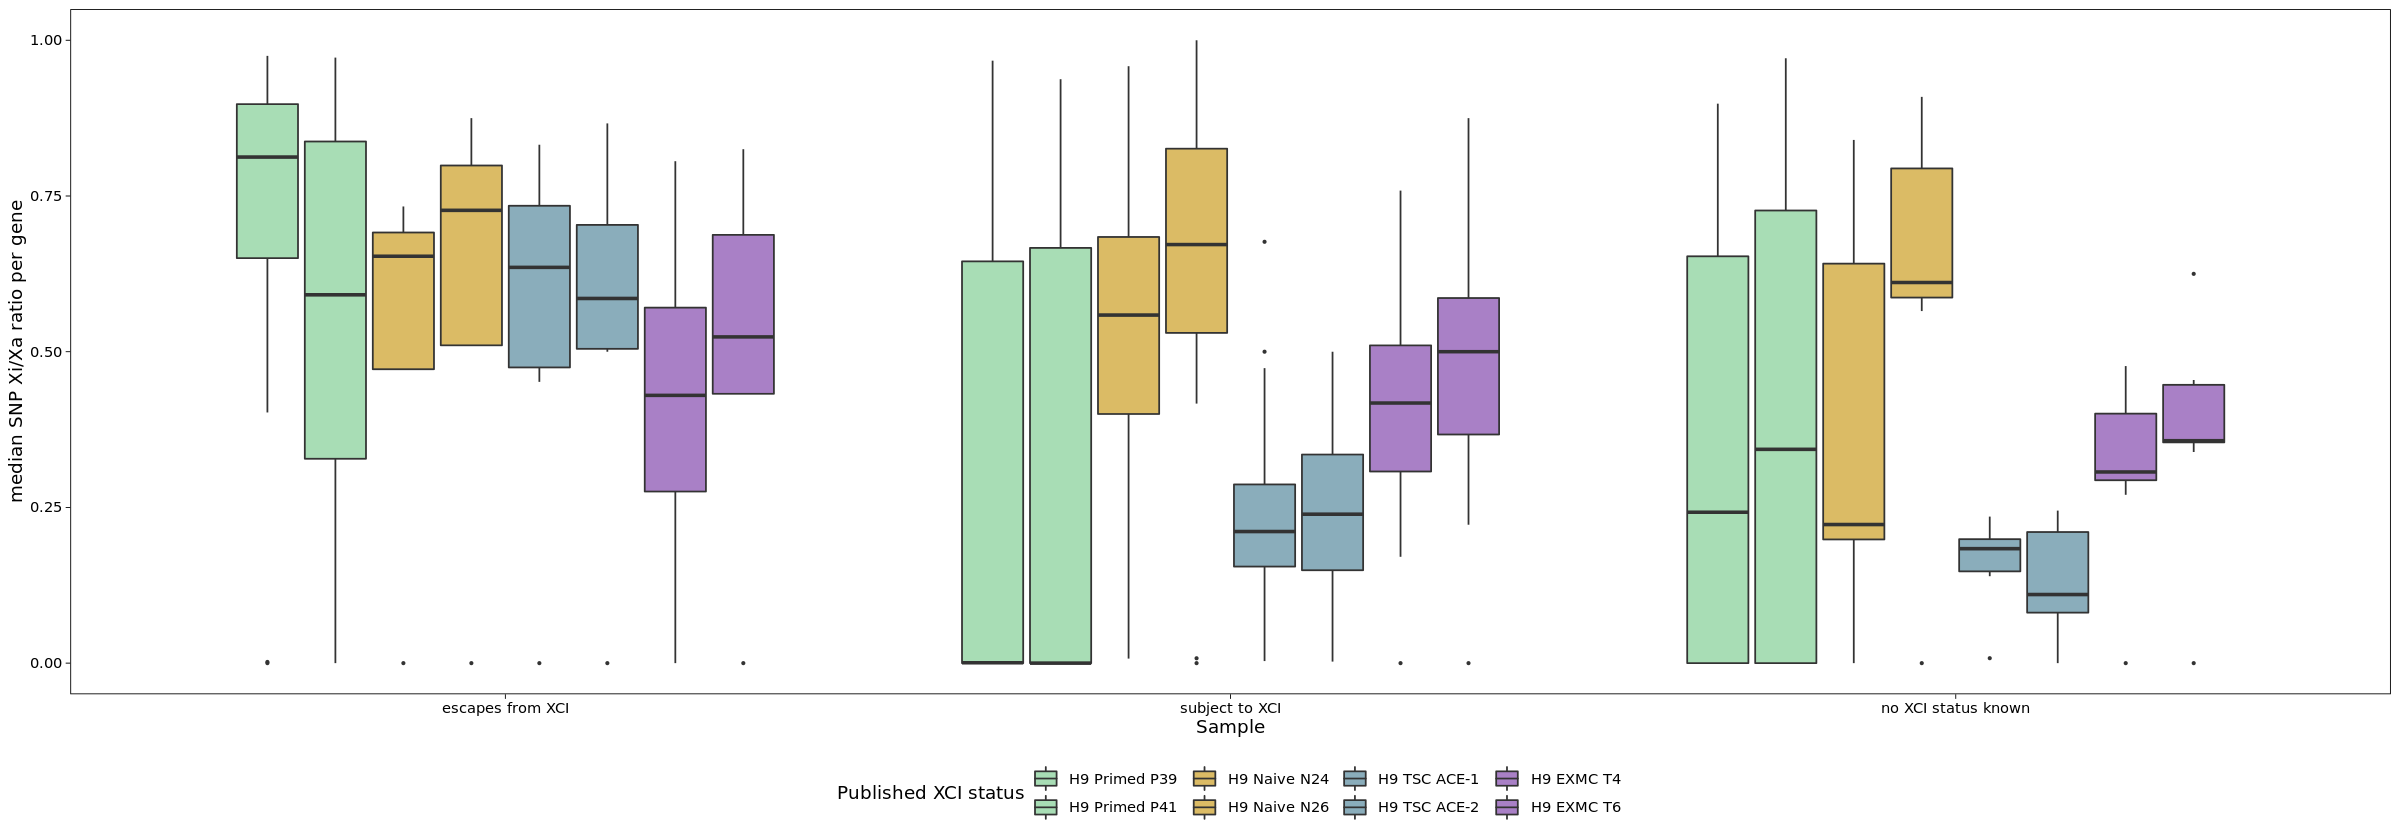

In [75]:
options(repr.plot.width=20)
#pdf(file=paste(c(outFilePrefix, "XiXaRatio.medianSNPperGene.wLegend.pdf"), collapse=""), height=4, width=10)
ggplot(allelicRatiosPerGeneStack[which(allelicRatiosPerGeneStack$status%in%c("autosomal", "escapes from XCI", "subject to XCI", "no XCI status known")),], aes(x=statusOrdered, y=values, fill=cellTypeOrdered))+
geom_boxplot(size=0.5, outlier.size = 0.5)+theme_linedraw()+ylab("median SNP Xi/Xa ratio per gene")+
xlab("Sample")+guides(fill=guide_legend(title = "Published XCI status"))+
scale_fill_manual(values=c("H9 Primed P39"="#a8ddb5",
                          "H9 Primed P41"="#a8ddb5",
                           "H9 Naive N24"="#DBBB65",
                          "H9 Naive N26"="#DBBB65",
                           "H9 TSC ACE-1"="#8AADBB",
                          "H9 TSC ACE-2"="#8AADBB",
                          "H9 EXMC T4"="#A980C6",
                          "H9 EXMC T6"="#A980C6"))+
theme(panel.grid= element_blank(), panel.grid.major.y=element_blank(), legend.position="bottom")
#dev.off()

In [93]:
allelicRatiosPerGeneStack$cellTypeSimplified <- NA
allelicRatiosPerGeneStack$cellTypeSimplified[which(allelicRatiosPerGeneStack$ind%in%c("H9 Primed P39", "H9 Primed P41"))]<- "Primed"
allelicRatiosPerGeneStack$cellTypeSimplified[which(allelicRatiosPerGeneStack$ind%in%c("H9 Naive N24", "H9 Naive N26"))]<- "Naive"
allelicRatiosPerGeneStack$cellTypeSimplified[which(allelicRatiosPerGeneStack$ind%in%c("H9 TSC ACE-1", "H9 TSC ACE-2"))]<- "TSC"
allelicRatiosPerGeneStack$cellTypeSimplified[which(allelicRatiosPerGeneStack$ind%in%c("H9 EXMC T4", "H9 EXMC T6"))]<- "EXMC"

allelicRatiosPerGeneStack$cellTypeSimplified <- factor(allelicRatiosPerGeneStack$cellTypeSimplified, levels=c("Primed","Naive", "TSC", "EXMC"))

In [106]:
options(repr.plot.width=5)
pdf(file=paste(c(outFilePrefix, "XiXaRatio.medianSNPperGene.simplified.subjectGenesOnly.noPrimed.pdf"), collapse=""), height=4, width=3)
ggplot(allelicRatiosPerGeneStack[which(allelicRatiosPerGeneStack$status%in%c("subject to XCI") & !allelicRatiosPerGeneStack$ind%in%c("H9 Primed P39", "H9 Primed P41")),], 
       aes(x=cellTypeSimplified, y=values*100, fill=cellTypeSimplified))+geom_violin(scale="width", alpha=0.5)+
theme_linedraw()+ylab("average allelic ratio per gene")+geom_boxplot(position=position_dodge(0.9), width=0.2, alpha=1)+
xlab("Cell Type")+guides(fill=guide_legend(title = "Gene allelic expression status in primed cells"))+
scale_fill_manual(values=c("Naive"="#DBBB65","TSC"="#8AADBB","EXMC"="#A980C6"))+
geom_hline(yintercept=c(25))+
theme(text = element_text(size=16), legend.position="none", panel.grid.major = element_blank(), panel.grid.minor=element_blank())
dev.off()

Warning message:
“Removed 646 rows containing non-finite values (stat_ydensity).”
Warning message:
“Removed 646 rows containing non-finite values (stat_boxplot).”


png 
  2

In [107]:
options(repr.plot.width=5)
pdf(file=paste(c(outFilePrefix, "XiXaRatio.medianSNPperGene.simplified.subjectGenesOnly.pdf"), collapse=""), height=4, width=3)
ggplot(allelicRatiosPerGeneStack[which(allelicRatiosPerGeneStack$status%in%c("subject to XCI") ),], 
       aes(x=cellTypeSimplified, y=values*100, fill=cellTypeSimplified))+geom_violin(scale="width", alpha=0.5)+
theme_linedraw()+ylab("average allelic ratio per gene")+geom_boxplot(position=position_dodge(0.9), width=0.2, alpha=1)+
xlab("Cell Type")+guides(fill=guide_legend(title = "Gene allelic expression status in primed cells"))+
scale_fill_manual(values=c("Naive"="#DBBB65","TSC"="#8AADBB","EXMC"="#A980C6", "Primed"="#a8ddb5"))+
geom_hline(yintercept=c(25))+
theme(text = element_text(size=16), legend.position="none", panel.grid.major = element_blank(), panel.grid.minor=element_blank())
dev.off()

Warning message:
“Removed 835 rows containing non-finite values (stat_ydensity).”
Warning message:
“Removed 835 rows containing non-finite values (stat_boxplot).”


png 
  2

<h2> making calls in primed and comparing other samples to them </h2>

In [ ]:
allelicRatiosPerGeneStack$callHere25Percent <- NA
allelicRatiosPerGeneStack$callPrimed25Percent <- NA

options(width=200)
for(i in unique(allelicRatiosPerGeneStack$gene[which(allelicRatiosPerGeneStack$status!="autosomal")])){
   # print(i)
    tempValues <- allelicRatiosPerGeneStack$values[which(allelicRatiosPerGeneStack$gene==i)]
    tempStatus <- character(length = length(tempValues))
    tempStatus[which(tempValues<0.25)] <- "Monoallelic"
    tempStatus[which(tempValues>0.25)] <- "Biallelic"
    
    allelicRatiosPerGeneStack$callHere25Percent[which(allelicRatiosPerGeneStack$gene==i)] <- tempStatus
    allelicRatiosPerGeneStack$callPrimed25Percent[which(allelicRatiosPerGeneStack$gene==i)] <- paste(unique(as.character(as.factor(
    allelicRatiosPerGeneStack$callHere25Percent[which(allelicRatiosPerGeneStack$gene==i & allelicRatiosPerGeneStack$ind%in%c("H9 Primed P39", "H9 Primed P41"))]))), collapse=",")
   # print(allelicRatiosPerGeneStack[which(allelicRatiosPerGeneStack$gene==i),])
}

In [ ]:
allelicRatiosPerGeneStack$callHere25Percent[which(allelicRatiosPerGeneStack$status=="autosomal")] <- "Autosomal"
allelicRatiosPerGeneStack$callPrimed25Percent[which(allelicRatiosPerGeneStack$status=="autosomal")] <- "Autosomal"

In [ ]:
#pdf(file=paste(c(outFilePrefix, "XiXaRatio.medianSNPperGene.organizedByPrimedNotXCIstatus.pdf"), collapse=""), height=6, width=12)


p <-ggplot(allelicRatiosPerGeneStack[which(allelicRatiosPerGeneStack$callPrimed25Percent%in%c("Autosomal", "Monoallelic", "Biallelic")),], 
       aes(x=ind, y=values*100, fill=callPrimed25Percent))+geom_violin(scale="width", alpha=0.5)+
theme_linedraw()+ylab("average allelic ratio per gene")+geom_boxplot(position=position_dodge(0.9), width=0.2, alpha=0.5)+
scale_fill_manual(values=c("Autosomal"="grey", "Biallelic"="#8AA1CE",
                                 "Monoallelic"="#FC8767"))+
xlab("Sample")+guides(fill=guide_legend(title = "Gene allelic expression status in primed cells"))+
geom_vline(xintercept = c(2.5, 4.5, 6.5))+
geom_hline(yintercept=c(25))

temp <- ggplot_build(p)$data[[2]]



p+geom_segment(data=temp, aes(x=xmin, xend=xmax, y=middle, yend=middle, fill=NA, color=as.character(fill)),  size=2)+
scale_color_manual(values=c("dark blue", "dark red", "black"), guide="none")+
theme(text = element_text(size=16), legend.position="bottom", panel.grid = element_blank())
#dev.off()

In [ ]:
t.test(allelicRatiosPerGeneStack$values[which(allelicRatiosPerGeneStack$callPrimed25Percent%in%c("Monoallelic", "Biallelic")&
                                          allelicRatiosPerGeneStack$status%in%c("subject to XCI")&
                                      allelicRatiosPerGeneStack$ind%in%c("H9 Naive N24","H9 Naive N26"))],
      allelicRatiosPerGeneStack$values[which(allelicRatiosPerGeneStack$callPrimed25Percent%in%c( "Monoallelic", "Biallelic")&
                                          allelicRatiosPerGeneStack$status%in%c("subject to XCI")&
                                     allelicRatiosPerGeneStack$ind%in%c("H9 EXMC T4", "H9 EXMC T6"))])

In [ ]:
#pdf(file=paste(c(outFilePrefix, "XiXaRatio.medianSNPperGene.organizedByPrimed.pdf"), collapse=""), height=12, width=12)


ggplot(allelicRatiosPerGeneStack[which(allelicRatiosPerGeneStack$callPrimed25Percent%in%c( "Autosomal","Monoallelic", "Biallelic")&
                                          allelicRatiosPerGeneStack$status%in%c("autosomal","escapes from XCI", "subject to XCI")),], 
       aes(x=ind, y=values*100, fill=callPrimed25Percent))+geom_violin(scale="width", alpha=0.5)+
theme_linedraw()+ylab("average allelic ratio per gene")+geom_boxplot(position=position_dodge(0.9), width=0.2, alpha=0.5)+
scale_fill_manual(values=c("Autosomal"="grey","Biallelic"="#8AA1CE",
                                 "Monoallelic"="#FC8767"))+
#scale_color_manual(guide="none", values=c("Biallelic"="#8AA1CE",
#                                 "Monoallelic"="#FC8767"))+
xlab("Sample")+guides(fill=guide_legend(title = "Gene allelic expression status in primed cells"))+
geom_vline(xintercept = c(2.5, 4.5, 6.5))+
geom_hline(yintercept=c(25))+
facet_wrap(~status, ncol=1)+
theme(text = element_text(size=16), legend.position="bottom", panel.grid=element_blank())

#dev.off()


<h3> Graphing % total expression, but phasing genome be which is expressed in prime </h3>

In [ ]:
#abbreviating primedExpressedAllele as PEA and Primed Silenced Allele as PSA
allReadTotalStack$PEA <- NA #
allReadTotalStack$PEA.val <- NA
allReadTotalStack$PSA.val <- NA

#limiting to X and with at least 30 reads, and mono-allelic in primed#I treid changing to 10+ because vincent thinks 30+ is too stringent

for(i in unique(allReadTotalStack$SNP[which(allReadTotalStack$chr=="chrX" & 
                                            allReadTotalStack$depth>9 & 
                                            allReadTotalStack$gene%in%allelicRatiosPerGeneStack$gene[which(allelicRatiosPerGeneStack$callPrimed25Percent=="Monoallelic")])])){
    #if value<value.1 in primed
    if(all(allReadTotalStack$values[which(allReadTotalStack$SNP==i & allReadTotalStack$ind%in%c("H9 Primed P39", "H9 Primed P41") & allReadTotalStack$chr=="chrX" & allReadTotalStack$depth>9)]<
      allReadTotalStack$values.1[which(allReadTotalStack$SNP==i & allReadTotalStack$ind%in%c("H9 Primed P39", "H9 Primed P41") & allReadTotalStack$chr=="chrX"& allReadTotalStack$depth>9)])){
        allReadTotalStack$PEA[which(allReadTotalStack$SNP==i & allReadTotalStack$chr=="chrX")] <- 1
        allReadTotalStack$PEA.val[which(allReadTotalStack$SNP==i & allReadTotalStack$chr=="chrX")] <- allReadTotalStack$values.1[which(allReadTotalStack$SNP==i & allReadTotalStack$chr=="chrX")]
        allReadTotalStack$PSA.val[which(allReadTotalStack$SNP==i & allReadTotalStack$chr=="chrX")] <- allReadTotalStack$values[which(allReadTotalStack$SNP==i & allReadTotalStack$chr=="chrX")]
    #if value>value.1 in primed    
    } else if(all(allReadTotalStack$values[which(allReadTotalStack$SNP==i & allReadTotalStack$ind%in%c("H9 Primed P39", "H9 Primed P41") & allReadTotalStack$chr=="chrX"& allReadTotalStack$depth>9)]>
      allReadTotalStack$values.1[which(allReadTotalStack$SNP==i & allReadTotalStack$ind%in%c("H9 Primed P39", "H9 Primed P41") & allReadTotalStack$chr=="chrX"& allReadTotalStack$depth>9)])){
        allReadTotalStack$PEA[which(allReadTotalStack$SNP==i & allReadTotalStack$chr=="chrX")] <- 2
        allReadTotalStack$PEA.val[which(allReadTotalStack$SNP==i & allReadTotalStack$chr=="chrX")] <- allReadTotalStack$values[which(allReadTotalStack$SNP==i & allReadTotalStack$chr=="chrX")]
        allReadTotalStack$PSA.val[which(allReadTotalStack$SNP==i & allReadTotalStack$chr=="chrX")] <- allReadTotalStack$values.1[which(allReadTotalStack$SNP==i & allReadTotalStack$chr=="chrX")]
   
    }
  
}

In [ ]:
allelicRatiosPerGeneStack$medianRatioVsPrimedAllele <- NA
allelicRatiosPerGeneStack$medianRatioVsPrimedAlleleDepthFilter10 <- NA
allelicRatiosPerGeneStack$medianRatioVsPrimedAlleleDepthFilter30 <- NA

for(i in which(allelicRatiosPerGeneStack$chr=="chrX")){
    rowsToAve <- which(allReadTotalStack$ind==as.character(allelicRatiosPerGeneStack$ind[i]) & allReadTotalStack$gene==allelicRatiosPerGeneStack$gene[i] & allReadTotalStack$depth>29)
    allelicRatiosPerGeneStack$medianRatioVsPrimedAlleleDepthFilter30[i] <- median(allReadTotalStack$PSA.val[rowsToAve]/(allReadTotalStack$PSA.val[rowsToAve]+allReadTotalStack$PEA.val[rowsToAve]), na.rm=T)
    
}

for(i in which(allelicRatiosPerGeneStack$chr=="chrX")){
    rowsToAve <- which(allReadTotalStack$ind==as.character(allelicRatiosPerGeneStack$ind[i]) & allReadTotalStack$gene==allelicRatiosPerGeneStack$gene[i] & allReadTotalStack$depth>9)
    allelicRatiosPerGeneStack$medianRatioVsPrimedAlleleDepthFilter10[i] <- median(allReadTotalStack$PSA.val[rowsToAve]/(allReadTotalStack$PSA.val[rowsToAve]+allReadTotalStack$PEA.val[rowsToAve]), na.rm=T)
    
}

for(i in which(allelicRatiosPerGeneStack$chr=="chrX")){
    rowsToAve <- which(allReadTotalStack$ind==as.character(allelicRatiosPerGeneStack$ind[i]) & allReadTotalStack$gene==allelicRatiosPerGeneStack$gene[i] )
    allelicRatiosPerGeneStack$medianRatioVsPrimedAllele[i] <- median(allReadTotalStack$PSA.val[rowsToAve]/(allReadTotalStack$PSA.val[rowsToAve]+allReadTotalStack$PEA.val[rowsToAve]), na.rm=T)
    
}

In [ ]:
#don't rerun this because it will delete more columns. only run once
allelicRatiosPerGeneStack<- unique(allelicRatiosPerGeneStack[,-2])

In [ ]:
allelicRatiosPerGeneStack$samplesWithNnoFilter <- factor(allelicRatiosPerGeneStack$ind)
allelicRatiosPerGeneStack$samplesWithNfilter10 <- factor(allelicRatiosPerGeneStack$ind)
allelicRatiosPerGeneStack$samplesWithNfilter30 <- factor(allelicRatiosPerGeneStack$ind)

In [ ]:
levels(allelicRatiosPerGeneStack$samplesWithNnoFilter) <- apply(NgenesPerSample[,c(1,5,2)], 1, paste, collapse="")
levels(allelicRatiosPerGeneStack$samplesWithNfilter10)<- apply(NgenesPerSample[,c(1,5,3)], 1, paste, collapse="")
levels(allelicRatiosPerGeneStack$samplesWithNfilter30)<- apply(NgenesPerSample[,c(1,5,4)], 1, paste, collapse="")

In [ ]:
options(repr.plot.width=30, repr.plot.height=5)
suppressWarnings(
grid.arrange(ggplot(allelicRatiosPerGeneStack, aes(x=samplesWithNnoFilter, y=medianRatioVsPrimedAllele, fill=ind))+geom_violin(scale="width", alpha=0.5)+geom_boxplot(width=0.1)+
theme_bw()+ylab("% of total expression from\nprimed silenced allele (per gene)")+xlab("sample")+theme(legend.position="none")+scale_fill_manual(values=c("red", "red", "blue", "blue", "orange", "orange", "purple","purple"))+ggtitle("no depth filter")
,
ggplot(allelicRatiosPerGeneStack, aes(x=samplesWithNfilter10, y=medianRatioVsPrimedAlleleDepthFilter10, fill=ind))+geom_violin(scale="width", alpha=0.5)+geom_boxplot(width=0.1)+
theme_bw()+ylab("% of total expression from\nprimed silenced allele (per gene)")+xlab("sample")+theme(legend.position="none")+scale_fill_manual(values=c("red", "red", "blue", "blue", "orange", "orange", "purple","purple"))+ggtitle("depth filter 10")
,
ggplot(allelicRatiosPerGeneStack, aes(x=samplesWithNfilter30, y=medianRatioVsPrimedAlleleDepthFilter30, fill=ind))+geom_violin(scale="width", alpha=0.5)+geom_boxplot(width=0.1)+
theme_bw()+ylab("% of total expression from\nprimed silenced allele (per gene)")+xlab("sample")+theme(legend.position="none")+scale_fill_manual(values=c("red", "red", "blue", "blue", "orange", "orange", "purple","purple"))+ggtitle("depth filter 30")
, ncol=3)
    )

In [ ]:
#with depth 30+
#pdf(file=paste(c(outFilePrefix, "percentExpressionPrimedSilencedAllele.pdf"), collapse=""), height=4, width=10)
ggplot(allelicRatiosPerGeneStack, aes(x=samplesWithN, y=medianRatioVsPrimedAlleleDepthFilter30, fill=ind))+geom_violin(scale="width", alpha=0.5)+geom_boxplot(width=0.1)+
theme_bw()+ylab("% of total expression from\nprimed silenced allele (per gene)")+xlab("sample")+theme(legend.position="none")+scale_fill_manual(values=c("red", "red", "blue", "blue", "orange", "orange", "purple","purple"))
#dev.off()

In [ ]:
#save(allelicRatiosPerGeneStack, file="AP.XCI.bulkRNAseq.allelicRatiosPerGeneStack.differentDepths.step1.Robject")

In [ ]:
load("AP.XCI.bulkRNAseq.allelicRatiosPerGeneStack.Robject")

In [ ]:
#save(allReadTotalStack, file="AP.XCI.bulkRNAseq.allReadTotalStack.Robject")
load("AP.XCI.bulkRNAseq.allReadTotalStack.Robject")